# **DEMO FACE ID Spoof Detector Model**

# Load Dataset

In [1]:

import zipfile
import os

# Unzip the dataset
zip_path = 'Demo_Dataset.zip'
extract_dir = './Demo_Dataset'

if not os.path.exists(extract_dir):
    if os.path.exists(zip_path):
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Extraction complete.")
    else:
        print(f"Error: {zip_path} not found. Please upload it to the current directory.")
else:
    print(f"Dataset already extracted at {extract_dir}")


Extracting Demo_Dataset.zip...
Extraction complete.


# Data transformation


In [2]:
from torchvision import transforms

# Image size for InceptionResnetV1 is typically 160x160, but handles 224 perfectly fine
IMG_SIZE = 224

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), #safeguard
    transforms.ToTensor(),
])


# Prepare Evaluation Dataset

In [3]:
from torchvision import datasets
from torch.utils.data import DataLoader
import torch
import os

# Load the full dataset as the test set
dataset_path = './Demo_Dataset/Demo_Dataset'
full_dataset = datasets.ImageFolder(root=dataset_path)

print(f"Detected classes: {full_dataset.classes}")
print(full_dataset.class_to_idx)

class TransformedDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

test_set = TransformedDataset(full_dataset, transform=val_transforms)
print(f"Evaluation set size: {len(test_set)}")


Detected classes: ['Real_Images', 'Spoof_Images']
{'Real_Images': 0, 'Spoof_Images': 1}
Evaluation set size: 511


# Data Loader

In [4]:
BATCH_SIZE = 16

test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

# Check by extracting one batch
images, labels = next(iter(test_loader))
print(f"Batch shape: {images.shape}") # Should be [16(images in batch), 3(color channels), 224, 224]


Batch shape: torch.Size([16, 3, 224, 224])


# Load pre trained model (model.pt)


In [5]:
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if os.path.exists("./model.pt"):
    model = torch.jit.load("./model.pt", map_location=device)
    model.eval()
    print("Successfully loaded model.pt")
else:
    print("Error: model.pt not found. Please upload it to the current directory.")


Using device: cpu
Successfully loaded model.pt


# **Results**

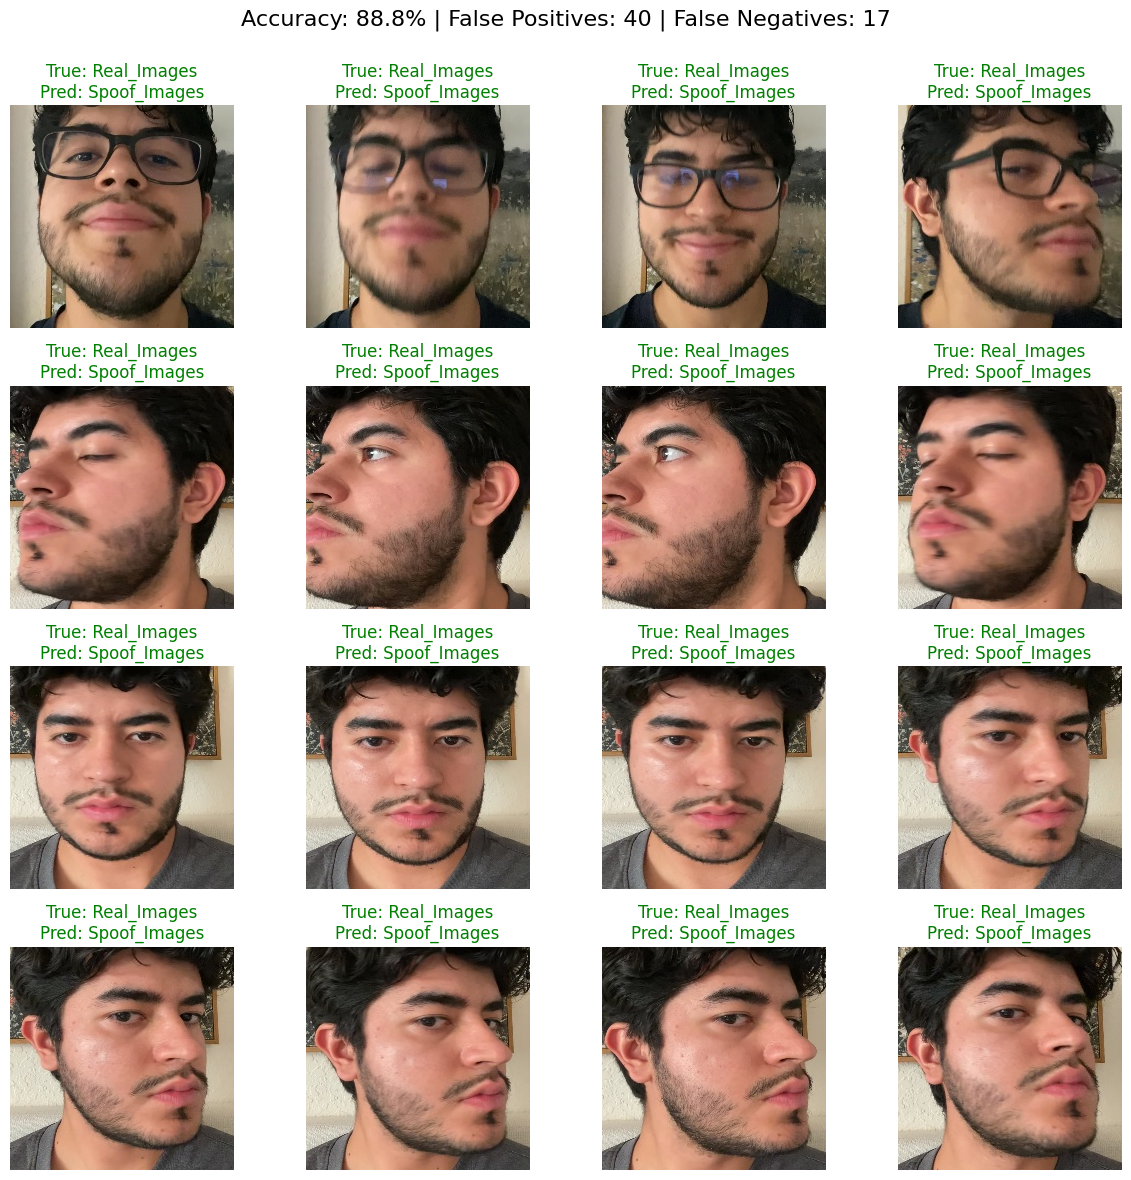

In [6]:
import matplotlib.pyplot as plt
import numpy as np

#  Error Analysis Grid
model.eval()
errors = []
error_labels = []
error_preds = []

class_names = full_dataset.classes

total_samples = 0
total_correct = 0
false_positives = 0
false_negatives = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        # predict
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        total_samples += labels.size(0)
        total_correct += (preds == labels).sum().item()

        # 'Real_Images' is class 0 and 'Spoof_Images' is class 1
        # False Positive: predicted spoof (1) but true is real (0)
        # False Negative: predicted real (0) but true is spoof (1)
        false_positives += ((preds == 1) & (labels == 0)).sum().item()
        false_negatives += ((preds == 0) & (labels == 1)).sum().item()

        # Find mismatches
        mismatches = (preds != labels).nonzero(as_tuple=True)[0]

        for idx in mismatches:
            if len(errors) < 16:
                errors.append(inputs[idx].cpu()) # image tensor
                error_labels.append(labels[idx].item()) # actual label
                error_preds.append(preds[idx].item()) # prediction

accuracy = (total_correct / total_samples) * 100 if total_samples > 0 else 0.0

if len(errors) > 0:
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    subtitle_str = f"Accuracy: {accuracy:.1f}% | False Positives: {false_positives} | False Negatives: {false_negatives}"

    # Set title
    fig.suptitle(subtitle_str, fontsize=16)

    axes = axes.flatten()

    for i in range(min(16, len(errors))):

        img = errors[i].permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        true_label = error_labels[i]
        pred_label = error_preds[i]

        true_class = class_names[true_label]
        pred_class = class_names[pred_label]

        # Determine text color: Green for False Positives, Red for False Negatives
        # False Positive: predicted spoof (1), actual real (0)
        title_color = 'green' if (pred_label == 1 and true_label == 0) else 'red'

        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_class}\nPred: {pred_class}", color=title_color)
        axes[i].axis('off')

    # Turn off any unused axes if there are fewer than 16 errors
    for i in range(len(errors), 16):
        axes[i].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9) # Provide space for the suptitle
    plt.show()
else:
    print(f"No errors found in the test set! Accuracy: {accuracy:.1f}%")
